In [5]:
#Import the Tensorflow library, tf is  an alias or a short name  to make it easier  when  writing codes
import tensorflow as tf
#Import datasets, layers, models from keras
from tensorflow.keras import datasets, layers, models
#Import numpy
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Load the dataset
mnist_digits = datasets.mnist #Accesses the MNIST dataset from Keras
(train_digits, train_labels), (test_digits, test_labels) = mnist_digits.load_data() #loads the dataset

In [ ]:
# Explore the data
print(train_digits.shape) #Display the shape of the training digits

(60000, 28, 28)


In [ ]:
print(train_labels.shape) #Display the shape of the training labels
print(train_labels) #Display the values of the training labels

(60000,)
[5 0 4 ... 5 6 8]


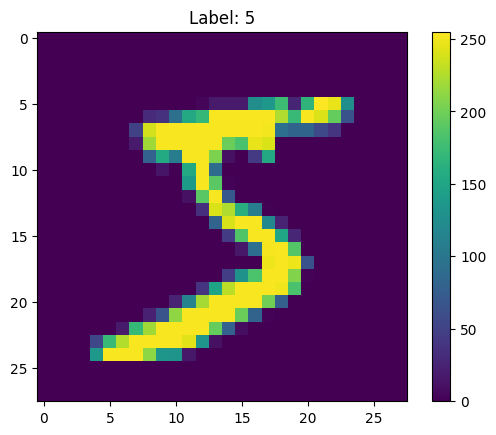

In [ ]:
# Visualize the data
plt.figure()
plt.imshow(train_digits[0]) # Display the first image in the plot area
plt.colorbar()
plt.title(f"Label: {train_labels[0]}") # Displays the label of the first image
plt.grid(False)
plt.show() # Render and displaysthe plot window.

In [ ]:
# Preprocess the data.  Scale the pixel values to have a range of 0 to 1.
train_digits = train_digits/255.0
test_digits = test_digits/255.0

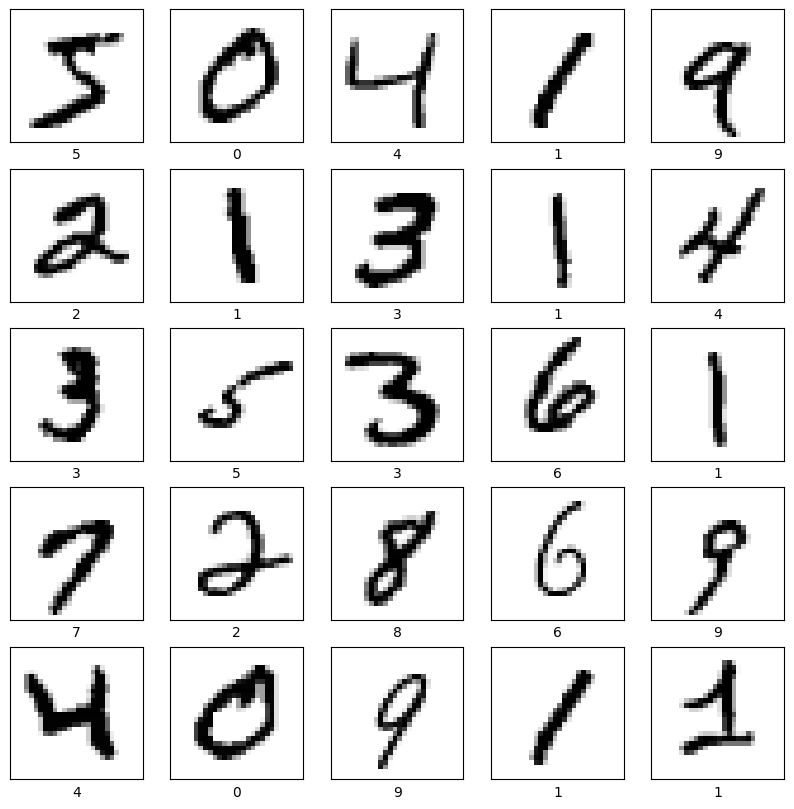

In [ ]:
plt.figure(figsize=(10,10))   # Create a new figure (canvas) with size 10x10 inches
for i in range(25):           # Loop 25 times to display the first 25 images
    plt.subplot(5,5,i+1)      # Create a 5x5 grid and select position (i+1) for current image
    plt.xticks([])            # Remove numbers from the x-axis
    plt.yticks([])            # Remove numbers from the y-axis
    plt.grid(False)           # Turn off the grid lines
    plt.imshow(train_digits[i], cmap=plt.cm.binary)  
                               # Display the i-th image using black & white colormap
    plt.xlabel(train_labels[i])  
                               # Show the label (actual digit) below the image
plt.show()                    # Display the complete figure with all images


In [7]:
# Build the model
model = models.Sequential()
model.add(layers.Input(shape=(28,28)))
model.add(layers.Flatten())#flatten layer 
model.add(layers.Dense(128, activation="relu"))#hidden layer
model.add(layers.Dense(10)) #output layer

In [ ]:
# Compile the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
# Train the model
model.fit(train_digits, train_labels, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9247 - loss: 0.2617
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9657 - loss: 0.1161
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9757 - loss: 0.0804
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9814 - loss: 0.0596
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9854 - loss: 0.0471
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9889 - loss: 0.0361
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9908 - loss: 0.0291
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9924 - loss: 0.0243
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9941 - loss: 0.0196
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9952 - loss: 0.0159


In [ ]:
# Evaluate the model.

test_loss, test_acc = model.evaluate(test_digits,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

313/313 - 1s - 3ms/step - accuracy: 0.9766 - loss: 0.0922

Test accuracy: 0.9765999913215637


In [8]:
# Make predictions
probability_model = models.Sequential([
    model,                         # The trained model (outputs logits/raw scores)
    layers.Softmax()       # Convert raw scores into probabilities
])

predictions = probability_model.predict(test_digits)  # Predict probabilities for test images


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 528us/step


In [ ]:
print(predictions[1])

[3.90305427e-11 6.57399113e-08 9.99999881e-01 7.36365080e-10
 1.28144445e-26 1.32069763e-11 1.34610153e-11 5.61712960e-18
 6.09738537e-10 1.35701421e-14]


In [ ]:
# Get predicted class (highest probability)
np.argmax(predictions[1])

np.int64(2)

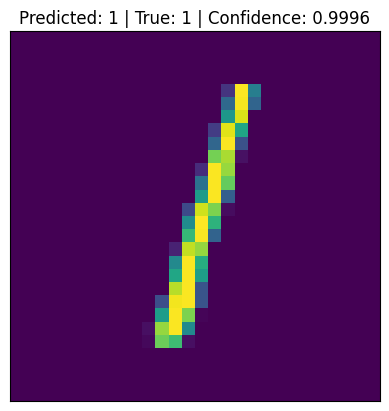

In [ ]:
#Verify the predictions
# Choose an image index to test
index = 2  

# Display the image
plt.imshow(test_digits[index])
plt.xticks([])
plt.yticks([])

# Get predicted class (highest probability)
predicted_label = np.argmax(predictions[index])

# Get true label
true_label = test_labels[index]

# Get confidence (highest probability value)
confidence = np.max(predictions[index])

# Show title with prediction details
plt.title(f"Predicted: {predicted_label} | True: {true_label} | Confidence: {confidence:.4f}")

plt.show()